# Education Module — LLM-as-a-Judge Evaluation

Evaluates chatbot responses in `actual_test_cases/education_result.xlsx` using the **calibrated judge prompt** (`prompt_4`) obtained from the alignment phase in `LLM_judge_alignment/aligned_education.ipynb`.

**Why prompt_4?**  
After 5 optimisation rounds the mismatch vs. golden labels converged to ≤ 30 % on every field:

| Prompt | faithfulness | relevance | simplicity | retrieval |
|--------|-------------|-----------|------------|----------|
| prompt_0 | 6.7 % | 60.0 % ✗ | 46.7 % ✗ | 13.6 % |
| prompt_1 | 6.7 % | 20.0 % | 46.7 % ✗ | 13.6 % |
| prompt_2 | 6.7 % | 23.3 % | 43.3 % ✗ | 9.1 % |
| prompt_3 | 3.3 % | 26.7 % | 46.7 % ✗ | 13.6 % |
| **prompt_4** | **10.0 %** | **23.3 %** | **16.7 %** | **9.1 %** |

**Scoring scale:** `"good"` / `"acceptable"` / `"invalid"`  
**Score fields:** `faithfulness`, `relevance`, `simplicity`, `retrieval`

In [1]:
import os
import re
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Configuration ─────────────────────────────────────────────────────────────
N8N_BASE_URL  = "https://alphamakeathon-automation.arisetech.dev"
WEBHOOK_PATH  = "9d6049fc-77c8-43e9-b71e-f734506f4f9d"
USE_TEST_URL  = False   # True → /webhook-test/…  |  False → /webhook/…

DATA_FILE     = "../actual_test_cases/education_result.xlsx"
OUTPUT_FILE   = "education_eval_results.xlsx"

SCORE_FIELDS  = ["faithfulness", "relevance", "simplicity", "retrieval"]
TIMEOUT       = 600     # seconds per request
RETRIES       = 2
DELAY_BETWEEN = 0.5     # seconds between rows


def get_webhook_url() -> str:
    prefix = "webhook-test" if USE_TEST_URL else "webhook"
    return f"{N8N_BASE_URL}/{prefix}/{WEBHOOK_PATH}"


print("Webhook URL:", get_webhook_url())

Webhook URL: https://alphamakeathon-automation.arisetech.dev/webhook/9d6049fc-77c8-43e9-b71e-f734506f4f9d


## Calibrated Judge Prompt — `prompt_4`

This is the final output of the alignment loop.  
Placeholders: **`{userMessage}`**, **`{actualResult}`**, **`{retrievedText}`**.  
Returns JSON with `faithfulness`, `relevance`, `simplicity`, `retrieval`,  
each valued **`"good"`** / **`"acceptable"`** / **`"invalid"`**.

In [2]:
JUDGE_PROMPT = """\
You are a Quality Assurance (QA) expert specializing in evaluating AI Chatbot responses for a **Thai bank**. Your task is to assess the chatbot's response based on the provided context and user question, with a deep understanding of Thai customer service expectations.

Your evaluation follows two main principles:
1.  **Fact Accuracy First**: The correctness of the information is the highest priority. An answer that is factually wrong is a failure, even if it seems helpful.
2.  **Safety Over Rejection**: It is better for the bot to be cautious and provide a safe, conditional answer or state it doesn't know, than to give a definitive "yes" or "no" that might be wrong.

## Evaluation Process
First, meticulously compare the `Chatbot Response` against the `Retrieved Context` to judge `faithfulness`. Then, assess `relevance`, `simplicity`, and `retrieval` based on the definitions below. Apply the special rules where applicable.

## Evaluation Criteria

### 1. faithfulness — Is the response factually accurate according to the context?
*This is about the correctness of claims made in the response, not how well it answers the question.*
- "good"       : All information in the response is 100% present and correct according to the context. The response contains no inaccuracies, however minor. This includes responses where the bot **synthesizes** multiple pieces of information from the context to provide a direct conclusion or a precise, targeted conditional answer.
- "acceptable" : The response is principally correct but contains minor flaws. For example:
                   - It **lists** correct conditions from the context without synthesizing them into a conclusion (a "Cautious Listing").
                   - It omits minor, non-critical details.
                   - It contains a slight inaccuracy that doesn't mislead the user on the core point (e.g., starting with "No information found" before providing the correct information from the context).
- "invalid"    : The response contains factual errors, contradicts the context, or hallucinates information not present in the context.

### 2. relevance — Does the response address the user's core question?
*This is about how directly and completely the question is answered. Distinguish between a helpful expert and a raw search engine.*
- "good"       : The response acts like an **expert advisor**. It directly and completely answers **all parts** of the user's specific question by **synthesizing** information into a conclusive, tailored answer. Examples include:
                   - Providing a definitive "yes" or "no" and explaining *why* by applying a specific rule from the context to the user's situation.
                   - Providing a targeted conditional answer that directly applies a key condition to the user (e.g., "Yes, you are eligible *if* you are an NPL").
                   - Correctly stating that the requested information is not present in the provided context.
- "acceptable" : The response acts like a **search engine result**. It provides on-topic information but requires the user to perform the final step of reasoning. This rating applies to common, less-helpful patterns:
                   - **Generic Information**: Describes a program but doesn't answer if the user is eligible or how it applies to their specific query (e.g., "Program X helps with debt" instead of answering "Can I pause my payments under Program X?").
                   - **Cautious Listing**: Simply lists eligibility criteria from the context without applying them to the user's stated situation.
                   - **Procedural Deflection**: Provides only a procedural next step (e.g., "Please contact the bank for details") instead of answering the question with the available information.
                   - **Partial Answer**: Answers only one part of a multi-part question.
                   - **Incorrect Refusal**: Incorrectly claims it cannot find the answer when the information **IS** present in the context.
- "invalid"    : The response is completely off-topic or fundamentally misunderstands the user's intent.

### 3. simplicity — Is the response clear and easy to understand?
- "good"       : Uses natural, concise language. Well-structured and easy to read.
- "acceptable" : Generally easy to follow, but may be too lengthy, overly formal, structured as a simple list, or contain minor structural flaws. This also includes responses that are **clearly phrased but dangerously misleading** because their `faithfulness` is "invalid".
- "invalid"    : Repetitive, circular, confusing, truly self-contradictory (e.g., says "yes" and "no" to the same question in a way that is incomprehensible), or uses incomprehensible language.

### 4. retrieval — Was the retrieved context appropriate for the question?
- "good"       : The context contains the specific information needed to fully answer the question, **or to confidently conclude that the answer is not available within the documentation**. The presence of other topically-related but non-essential information is acceptable.
- "acceptable" : The context is on the right topic but lacks the specific details needed to form a complete and definitive answer. It is too general.
- "invalid"    : The context is irrelevant or from a completely wrong product/topic.

## Special Rules
1.  **Rule for Factual Errors**: If `faithfulness` is "invalid", `relevance` MUST be rated "acceptable" as long as the response was on the correct topic. This acknowledges the bot understood the question's topic even if its answer was factually wrong.

## Input Data

Retrieved Context:
{retrievedText}

Customer Question:
{userMessage}

Chatbot Response:
{actualResult}

## Output Instructions
Return ONLY a JSON object — no markdown, no explanation:
{{
  "faithfulness": "good" | "acceptable" | "invalid",
  "relevance":    "good" | "acceptable" | "invalid",
  "simplicity":  "good" | "acceptable" | "invalid",
  "retrieval":   "good" | "acceptable" | "invalid"
}}"""

print(f"Judge prompt loaded: {len(JUDGE_PROMPT)} chars")

Judge prompt loaded: 6003 chars


## Helper Functions

In [3]:
def fill_prompt(template: str, userMessage: str, actualResult: str, retrievedText: str) -> str:
    return (
        template
        .replace("{userMessage}",   str(userMessage))
        .replace("{actualResult}",  str(actualResult))
        .replace("{retrievedText}", str(retrievedText))
    )


def _call_raw(payload: dict, timeout: int = TIMEOUT, retries: int = RETRIES):
    url = get_webhook_url()
    last_exc: Exception | None = None
    for attempt in range(retries + 1):
        try:
            resp = requests.post(url, json=payload, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
    raise last_exc


def call_webhook(prompt: str):
    return _call_raw({"input": prompt})


def get_response_text(resp) -> str:
    if isinstance(resp, str):
        return resp
    if isinstance(resp, dict):
        for key in ("output", "text", "result", "response", "content", "message"):
            if key in resp and resp[key] is not None:
                return str(resp[key])
        return json.dumps(resp, ensure_ascii=False)
    return str(resp)


def parse_json_response(resp) -> dict:
    text = get_response_text(resp)
    # 1. markdown code block
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    # 2. whole text as JSON
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    # 3. first JSON object found
    m = re.search(r"(\{[\s\S]*?\})", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    return {}


print("Helpers ready.")

Helpers ready.


## Load Test Data

In [4]:
df = pd.read_excel(DATA_FILE)
print(f"Loaded {len(df)} test cases")
print("Columns:", df.columns.tolist())
print("\nragFocus distribution:")
print(df["ragFocus"].value_counts().to_string())
df.head(3)

Loaded 98 test cases
Columns: ['ragFocus', 'testId', 'userMessage', 'actualResult', 'retrievedText']

ragFocus distribution:
ragFocus
คุณสู้                  68
ปึกษาปัญหาหนี้ทั่วไป    30


,ragFocus,testId,userMessage,actualResult,retrievedText
0,คุณสู้,TC-001,ผ่อนบ้านมา 2 ปี ยอดกู้ 3.5 ล้าน ตอนนี้ตกงานค้า...,สวัสดีค่ะ สำหรับกรณีสินเชื่อบ้านของคุณที่มีวงเ...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...
1,คุณสู้,TC-002,อยากเข้าโครงการที่ลดค่างวดครึ่งนึงค่ะ ผ่อนรถยน...,ขออภัยค่ะ สำหรับโครงการ “จ่ายตรง คงทรัพย์” (มา...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...
2,คุณสู้,TC-003,พิ่งกู้ซื้อคอนโด 3 ล้าน เมื่อกุมภาปี 67 ตอนนี้...,สวัสดีค่ะ สำหรับสินเชื่อบ้านวงเงิน 3 ล้านบาท ห...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...


## Run Evaluation

For each row in `education_result.xlsx`:
1. Fill `{userMessage}`, `{actualResult}`, `{retrievedText}` into the calibrated judge prompt.
2. POST `{"input": filled_prompt}` to the webhook.
3. Parse JSON response → extract `faithfulness`, `relevance`, `simplicity`, `retrieval`.
4. Save full results to `education_eval_results.xlsx`.

If `education_eval_results.xlsx` already exists, the evaluation is **skipped** and the existing file is loaded.

In [5]:
if os.path.exists(OUTPUT_FILE):
    print(f"Results already exist → {OUTPUT_FILE}  (skipping evaluation)")
    df_results = pd.read_excel(OUTPUT_FILE)
else:
    predicted: list[dict] = []
    errors:    list[str | None] = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
        try:
            filled = fill_prompt(
                JUDGE_PROMPT,
                row["userMessage"],
                row["actualResult"],
                row["retrievedText"],
            )
            raw    = call_webhook(filled)
            parsed = parse_json_response(raw)
            predicted.append({f: parsed.get(f) for f in SCORE_FIELDS})
            errors.append(None)
        except Exception as exc:
            predicted.append({f: None for f in SCORE_FIELDS})
            errors.append(str(exc))
        time.sleep(DELAY_BETWEEN)

    df_pred = pd.DataFrame(predicted)

    df_results = df[["ragFocus", "testId", "userMessage", "actualResult", "retrievedText"]].copy()
    for f in SCORE_FIELDS:
        df_results[f] = df_pred[f].values
    df_results["error"] = errors

    df_results.to_excel(OUTPUT_FILE, index=False)
    print(f"Saved → {OUTPUT_FILE}")

print(f"\nTotal rows evaluated: {len(df_results)}")
error_count = df_results["error"].notna().sum() if "error" in df_results.columns else 0
print(f"Errors / parse failures: {error_count}")
df_results.head(3)

Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

Saved → education_eval_results.xlsx

Total rows evaluated: 98
Errors / parse failures: 0


,ragFocus,testId,userMessage,actualResult,retrievedText,faithfulness,relevance,simplicity,retrieval,error
0,คุณสู้,TC-001,ผ่อนบ้านมา 2 ปี ยอดกู้ 3.5 ล้าน ตอนนี้ตกงานค้า...,สวัสดีค่ะ สำหรับกรณีสินเชื่อบ้านของคุณที่มีวงเ...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...,good,good,good,good,None
1,คุณสู้,TC-002,อยากเข้าโครงการที่ลดค่างวดครึ่งนึงค่ะ ผ่อนรถยน...,ขออภัยค่ะ สำหรับโครงการ “จ่ายตรง คงทรัพย์” (มา...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...,good,good,good,good,None
2,คุณสู้,TC-003,พิ่งกู้ซื้อคอนโด 3 ล้าน เมื่อกุมภาปี 67 ตอนนี้...,สวัสดีค่ะ สำหรับสินเชื่อบ้านวงเงิน 3 ล้านบาท ห...,[file_name: khunsoo-v3p0.txt | lines: 1-6]\nโค...,good,good,good,good,None


## Results Summary

### Overall score distributions

In [6]:
LABEL_ORDER = ["good", "acceptable", "invalid"]
LABEL_COLORS = {"good": "#4caf50", "acceptable": "#ff9800", "invalid": "#f44336"}

print("=" * 55)
print("SCORE DISTRIBUTIONS — all test cases")
print("=" * 55)

summary_rows = []
for f in SCORE_FIELDS:
    counts = df_results[f].value_counts()
    total  = counts.sum()
    row = {"field": f}
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        row[lbl]          = n
        row[f"{lbl}_%"]   = f"{n / total:.1%}" if total else "—"
    summary_rows.append(row)
    print(f"  {f:15s}: ", end="")
    for lbl in LABEL_ORDER:
        n = counts.get(lbl, 0)
        print(f"{lbl}={n} ({n/total:.0%})  ", end="")
    print()

df_summary = pd.DataFrame(summary_rows)
df_summary

SCORE DISTRIBUTIONS — all test cases
  faithfulness   : good=88 (90%)  acceptable=2 (2%)  invalid=8 (8%)  
  relevance      : good=78 (80%)  acceptable=19 (19%)  invalid=1 (1%)  
  simplicity     : good=93 (95%)  acceptable=5 (5%)  invalid=0 (0%)  
  retrieval      : good=85 (87%)  acceptable=4 (4%)  invalid=9 (9%)  


,field,good,good_%,acceptable,acceptable_%,invalid,invalid_%
0,faithfulness,88,89.8%,2,2.0%,8,8.2%
1,relevance,78,79.6%,19,19.4%,1,1.0%
2,simplicity,93,94.9%,5,5.1%,0,0.0%
3,retrieval,85,86.7%,4,4.1%,9,9.2%


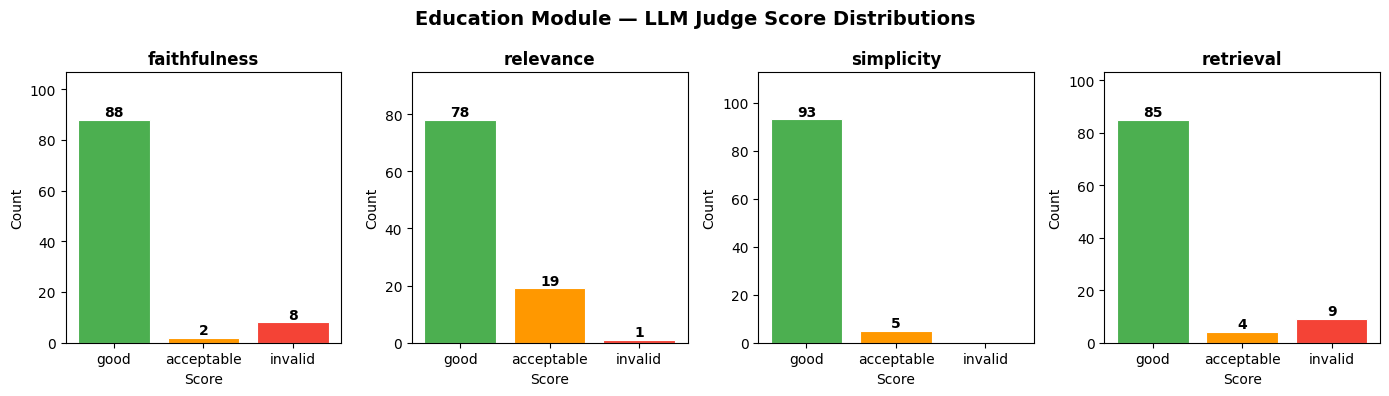

Chart saved → education_score_distribution.png


In [7]:
fig, axes = plt.subplots(1, len(SCORE_FIELDS), figsize=(14, 4), sharey=False)
fig.suptitle("Education Module — LLM Judge Score Distributions", fontsize=14, fontweight="bold")

for ax, f in zip(axes, SCORE_FIELDS):
    counts = df_results[f].value_counts().reindex(LABEL_ORDER, fill_value=0)
    colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
    bars   = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f, fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(val),
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )
    ax.set_ylim(0, max(counts.values) * 1.2 + 1)

plt.tight_layout()
plt.savefig("education_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → education_score_distribution.png")

### Score distributions by RAG focus

In [8]:
rag_groups = df_results["ragFocus"].unique()
print("=" * 55)
print("SCORE DISTRIBUTIONS — by ragFocus")
print("=" * 55)

for rag in sorted(rag_groups):
    sub = df_results[df_results["ragFocus"] == rag]
    print(f"\n  ragFocus: {rag}  (n={len(sub)})")
    for f in SCORE_FIELDS:
        counts = sub[f].value_counts()
        total  = counts.sum()
        print(f"    {f:15s}: ", end="")
        for lbl in LABEL_ORDER:
            n = counts.get(lbl, 0)
            print(f"{lbl}={n} ({n/total:.0%})  ", end="")
        print()

SCORE DISTRIBUTIONS — by ragFocus

  ragFocus: คุณสู้  (n=68)
    faithfulness   : good=62 (91%)  acceptable=2 (3%)  invalid=4 (6%)  
    relevance      : good=55 (81%)  acceptable=12 (18%)  invalid=1 (1%)  
    simplicity     : good=66 (97%)  acceptable=2 (3%)  invalid=0 (0%)  
    retrieval      : good=58 (85%)  acceptable=2 (3%)  invalid=8 (12%)  

  ragFocus: ปึกษาปัญหาหนี้ทั่วไป  (n=30)
    faithfulness   : good=26 (87%)  acceptable=0 (0%)  invalid=4 (13%)  
    relevance      : good=23 (77%)  acceptable=7 (23%)  invalid=0 (0%)  
    simplicity     : good=27 (90%)  acceptable=3 (10%)  invalid=0 (0%)  
    retrieval      : good=27 (90%)  acceptable=2 (7%)  invalid=1 (3%)  


/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_68478/642419648.py:31: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_68478/642419648.py:31: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_68478/642419648.py:31: UserWarning: Glyph 3603 (\N{THAI CHARACTER NO NEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_68478/642419648.py:31: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ipykernel_68478/642419648.py:31: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/03/p4dpz1wn4f1597xtdsx_f0800000gn/T/ip

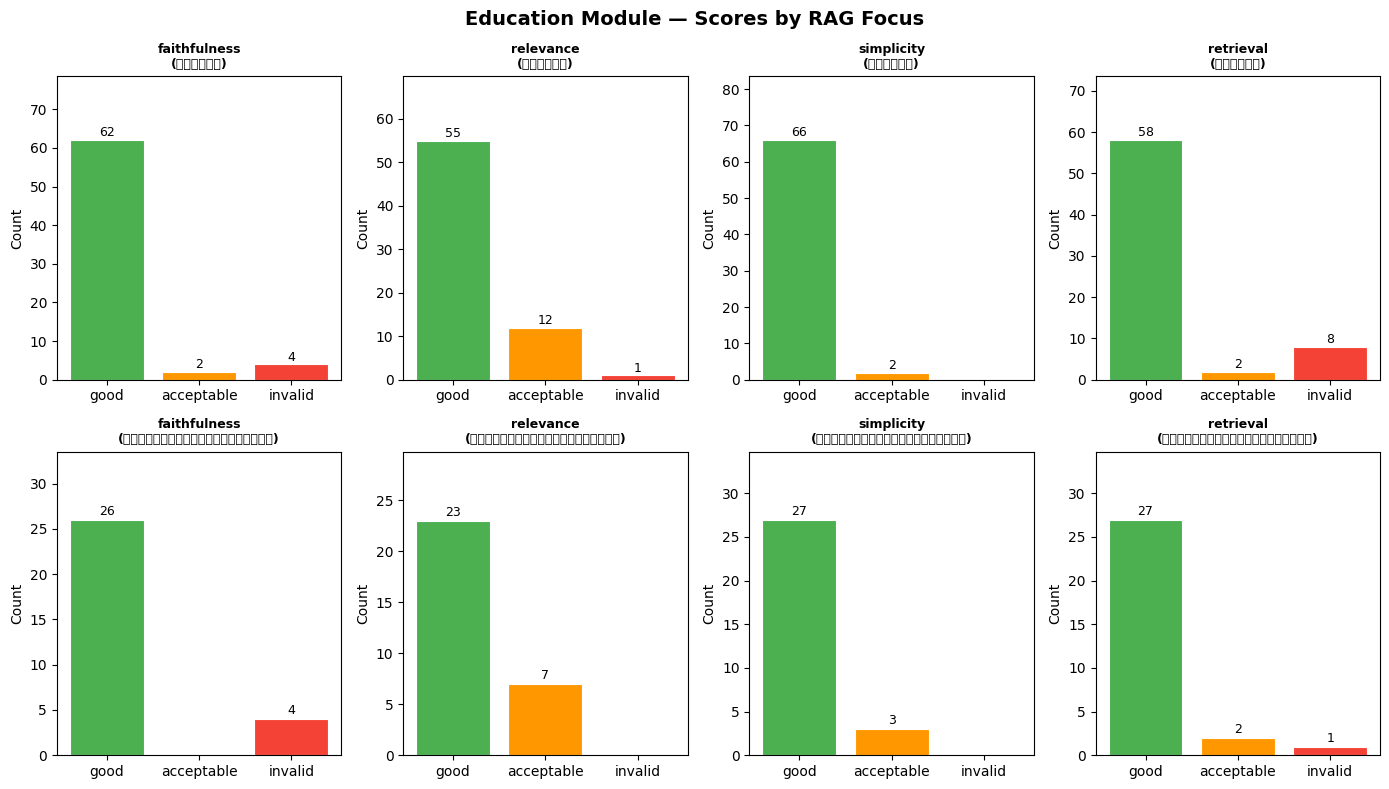

Chart saved → education_score_by_ragfocus.png


In [9]:
n_rag = len(rag_groups)
fig, axes = plt.subplots(
    n_rag, len(SCORE_FIELDS),
    figsize=(14, 4 * n_rag),
    sharey=False,
)
if n_rag == 1:
    axes = [axes]

fig.suptitle("Education Module — Scores by RAG Focus", fontsize=14, fontweight="bold")

for row_i, rag in enumerate(sorted(rag_groups)):
    sub = df_results[df_results["ragFocus"] == rag]
    for col_i, f in enumerate(SCORE_FIELDS):
        ax = axes[row_i][col_i]
        counts = sub[f].value_counts().reindex(LABEL_ORDER, fill_value=0)
        colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
        bars   = ax.bar(LABEL_ORDER, counts.values, color=colors, edgecolor="white", linewidth=0.8)
        ax.set_title(f"{f}\n({rag})", fontsize=9, fontweight="bold")
        ax.set_ylabel("Count")
        for bar, val in zip(bars, counts.values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.2,
                    str(val),
                    ha="center", va="bottom", fontsize=9,
                )
        ax.set_ylim(0, max(counts.values) * 1.25 + 1)

plt.tight_layout()
plt.savefig("education_score_by_ragfocus.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → education_score_by_ragfocus.png")

### Pass rate (good + acceptable) per field

In [10]:
print("=" * 55)
print("PASS RATE  (good + acceptable)")
print("=" * 55)

pass_rows = []
for f in SCORE_FIELDS:
    total   = df_results[f].notna().sum()
    n_good  = (df_results[f] == "good").sum()
    n_acc   = (df_results[f] == "acceptable").sum()
    n_inv   = (df_results[f] == "invalid").sum()
    pass_n  = n_good + n_acc
    pass_r  = pass_n / total if total else 0
    fail_r  = n_inv  / total if total else 0
    print(f"  {f:15s}: pass={pass_r:.1%}  (good={n_good/total:.1%}, acceptable={n_acc/total:.1%})  |  invalid={fail_r:.1%}")
    pass_rows.append({
        "field":      f,
        "total":      total,
        "good":       n_good,
        "acceptable": n_acc,
        "invalid":    n_inv,
        "pass_rate":  f"{pass_r:.1%}",
        "fail_rate":  f"{fail_r:.1%}",
    })

df_pass = pd.DataFrame(pass_rows)
df_pass

PASS RATE  (good + acceptable)
  faithfulness   : pass=91.8%  (good=89.8%, acceptable=2.0%)  |  invalid=8.2%
  relevance      : pass=99.0%  (good=79.6%, acceptable=19.4%)  |  invalid=1.0%
  simplicity     : pass=100.0%  (good=94.9%, acceptable=5.1%)  |  invalid=0.0%
  retrieval      : pass=90.8%  (good=86.7%, acceptable=4.1%)  |  invalid=9.2%


,field,total,good,acceptable,invalid,pass_rate,fail_rate
0,faithfulness,98,88,2,8,91.8%,8.2%
1,relevance,98,78,19,1,99.0%,1.0%
2,simplicity,98,93,5,0,100.0%,0.0%
3,retrieval,98,85,4,9,90.8%,9.2%


### Cases flagged `invalid` on any field

In [11]:
invalid_mask = (df_results[SCORE_FIELDS] == "invalid").any(axis=1)
df_invalid   = df_results[invalid_mask][["ragFocus", "testId", "userMessage"] + SCORE_FIELDS].reset_index(drop=True)

print(f"Cases with at least one 'invalid' score: {len(df_invalid)} / {len(df_results)}")
if len(df_invalid):
    print("\nBreakdown by ragFocus:")
    print(df_invalid["ragFocus"].value_counts().to_string())
    display(df_invalid)

Cases with at least one 'invalid' score: 15 / 98

Breakdown by ragFocus:
ragFocus
คุณสู้                  10
ปึกษาปัญหาหนี้ทั่วไป     5


,ragFocus,testId,userMessage,faithfulness,relevance,simplicity,retrieval
0,คุณสู้,TC-020,มีหนี้อยู่ก้อนนึง ผ่อนไม่ไหวแล้ว อยากเข้าโครงก...,invalid,acceptable,acceptable,acceptable
1,คุณสู้,TC-023,"ปกติผ่อนบ้านเดือนละ 10,000 ถ้าเข้าโครงการนี้ปี...",invalid,acceptable,acceptable,good
2,ปึกษาปัญหาหนี้ทั่วไป,TC-044,"""ถ้าอยากคุยเรื่องปัญหาหนี้ ต้องติดต่อใครในธนาคาร""",invalid,acceptable,good,acceptable
3,ปึกษาปัญหาหนี้ทั่วไป,TC-054,"""สนใจรีไฟแนนซ์ไปแบงก์อื่น ต้องเสียค่าอะไรเพิ่ม...",good,good,good,invalid
4,ปึกษาปัญหาหนี้ทั่วไป,TC-057,"""ถ้าเอาบ้านไปค้ำเพื่อรวมหนี้ จะมีความเสี่ยงอะไ...",invalid,acceptable,acceptable,good
5,ปึกษาปัญหาหนี้ทั่วไป,TC-063,"""จะครบกำหนดพักหนี้แล้วแต่ยังหางานไม่ได้เลย ต้อ...",invalid,acceptable,acceptable,good
6,ปึกษาปัญหาหนี้ทั่วไป,TC-070,"""แบงก์ไม่ยอมให้พักหนี้เลย ทั้งที่เดือดร้อนจริง...",invalid,acceptable,acceptable,acceptable
7,คุณสู้,TC-084,"""กินข้าวหรือยังจ๊ะบอท วันนี้มีเมนูอะไรแนะนำไหม""",good,good,good,invalid
8,คุณสู้,TC-086,"""บอทโง่มาก ถามอะไรก็ตอบไม่ได้เลย""",invalid,invalid,good,invalid
9,คุณสู้,TC-087,"""พรุ่งนี้ฝนจะตกไหม แถวพหลโยธิน""",good,good,good,invalid


### Cases with all fields `good`

In [12]:
all_good_mask = (df_results[SCORE_FIELDS] == "good").all(axis=1)
df_all_good   = df_results[all_good_mask][["ragFocus", "testId"] + SCORE_FIELDS].reset_index(drop=True)

print(f"Cases with all fields 'good': {len(df_all_good)} / {len(df_results)}  ({len(df_all_good)/len(df_results):.1%})")
if len(df_all_good):
    display(df_all_good)

Cases with all fields 'good': 70 / 98  (71.4%)


,ragFocus,testId,faithfulness,relevance,simplicity,retrieval
0,คุณสู้,TC-001,good,good,good,good
1,คุณสู้,TC-002,good,good,good,good
2,คุณสู้,TC-003,good,good,good,good
3,คุณสู้,TC-004,good,good,good,good
4,คุณสู้,TC-006,good,good,good,good
...,...,...,...,...,...,...
65,คุณสู้,TC-085,good,good,good,good
66,คุณสู้,TC-090,good,good,good,good
67,คุณสู้,TC-094,good,good,good,good
68,คุณสู้,TC-096,good,good,good,good
